# Wstęp
Zadanie 7 stanowi wprowadzenie w tematykę transfer learning i wykorzystywania gotowych, publicznie udostępnianych modeli. W praktyce, dla zadań tak złożonych jak analiza obrazu, o wiele łatwiej jest dostosować istniejące już i wyuczone na dużych zbiorach danych modele do nowego zaadania, niż wyuczyć własny model od zera. Jako bardziej interesujący przykład zastosowania gotowych modeli zostanie pokazany też transfer stylu obrazów.

# Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    mechanizmem importowania modeli
*    możliwościami wykorzystaniem transfer learningu do własnych zadań
*    transferem stylu jako przykładem wykorzystania cech z pretrenowanej architektury

# Importowanie modeli

Importowanie w torchu realizować będziemy poprzez ładowanie zapisanego obiektu słownika z wszystkimi parametrami warstw. Warto pamiętać tutaj, że słownik ten nie zapamiętuje pełnej struktury sieci, a jedynie parametry! Dlatego z jednej strony dla wczytania gotowego modelu konieczne jest istnienie odpowiedniej architektury w kodzie (zaimplementowany `torch.nn.Module` realizujący tę architekturę). Z drugiej zaś, słownik parametrów zgodny pod względem nazw i kształtów parametrów z zadaną architekturą możemy wczytać do dowolnej, dostosowanej do naszych potrzeb klasy - w szczególności umożliwiając nam własną implementację `forward`. Na razie sprawdźmy model, który ma już swoją implementację w `torchvision`: klasyczną architekturę VGG.

In [1]:
import torch
import torchvision.models as models
from matplotlib import pyplot as plt


vgg19 = models.vgg19(pretrained=True)

print(vgg19)

/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548M/548M [01:48<00:00, 5.29MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

W kontekście vgg19, interesuje nas szczególnie moduł features: instancja `torch.nn.Sequential', obejmująca konwolucyjną część architektury. Dla nowych zadań analizy obrazów, możemy wykorzystać tę częśc z własnym klassyfikatorem.

In [2]:
print(vgg19.features)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

Tutaj warto zwrócić jeszcze uwagę na przydatną własność `torch.nn.Sequential`: ta klasa jest indeksowalna, a kiedy korzystamy z indeksowania aby zwócić ciąg następujących po sobie elementów, zwracana jest również instancja `torch.nn.Sequential`:

In [3]:
print(f"pod indeksem 3 jest: {vgg19.features[3]}")
print(f"pod indeksami 3 do 7 jest: {vgg19.features[3:7]}")

pod indeksem 3 jest: ReLU(inplace=True)
pod indeksami 3 do 7 jest: Sequential(
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
)


# Zadanie 1

Zdefiniuj klasę LabVGG19, która inicjalizuje swoje parametry poprzez wczytanie wyuczonego modelu z torchvision.models, ale jej `forward` zwraca na wyjściu krotkę lub listę `out` gdzie



*   `out[0]` - cechy z poziomu architektury poprzedzającego pierwszy Max Pooling
*    `out[1]` - cechy z poziomu architektury poprzedzającego drugi Max Pooling
*    `out[2]` - cechy z poziomu architektury poprzedzającego trzeci Max Pooling


In [4]:
class LabVGG19(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        # Wczytanie pretrenowanego modelu VGG19
        vgg19 = models.vgg19(pretrained=True)
        
        # Pierwszy MaxPool2d znajduje się pod indeksem 4.
        # Więc bierzemy warstwy od 0 do 3 (włącznie z warstwą ReLU przed poolingiem)
        self.features1 = vgg19.features[:4]
        
        # Drugi MaxPool2d znajduje się pod indeksem 9.
        # Bierzemy pierwszego MaxPoola (indeks 4) i wszystkie warstwy aż do ReLU (indeks 8)
        self.features2 = vgg19.features[4:9]
        
        # Trzeci MaxPool2d znajduje się pod indeksem 18.
        # Bierzemy warstwy od drugiego MaxPoola (indeks 9) do ReLU przed trzecim poolingiem (indeks 17)
        self.features3 = vgg19.features[9:18]

    def forward(self, x):
        out1 = self.features1(x)
        out2 = self.features2(out1)
        out3 = self.features3(out2)
        
        return out1, out2, out3


Zweryfikuj działanie architektury

In [5]:
model = LabVGG19()
dummy_input = torch.zeros((3,3,32,32))
out = model(dummy_input)

assert(out[0].shape == (3,64,32,32))
assert(out[1].shape == (3,128,16,16))
assert(out[2].shape == (3,256,8,8))

/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Transfer Learning

Mając możliwość wydobywania cech z dowolnego poziomu architektury, możemy łatwo wykorzystać je do dowolnych nowych zadań. Wystarczy zbudować model, który przetwarza jako wejście to, co wynika z naszego wcześniejszego przetwarzania przez wyuczoną już sieć. Zaimportowaną część sieci możemy zarówno **douczać** jak i **zamrozić** w zależności od tego czy jej parametry podamy przy naszym uczeniu do optymalizowania. W tym drugim przypadku, warto pamiętać o wyłączeniu gradientów dla zamrożonych warstw.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.


**VGG na wejściu oczekuje danych znormalizowanych, z określonymi wartościami średniej i odchylenia standardowego. Transformacja wejściowa powinna korzystać z `transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))`.**

In [11]:
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from typing import Tuple, Dict, List
from tqdm import tqdm
import copy
import numpy as np
from sklearn.metrics import f1_score


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

full_train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=True, download=True)
train_ds, val_ds = random_split(full_train_ds, [int(0.9 * len(full_train_ds)), len(full_train_ds) - int(0.9 * len(full_train_ds))])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[float, float, float]:
    model.eval()
    total_loss = 0
    correct = 0
    all_preds = []
    all_labels = []
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            
            # CrossEntropyLoss returns mean by default, so we multiply by batch size to get sum
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item() * len(y_batch)
            
            preds = torch.argmax(y_pred, dim=1)
            correct += (preds == y_batch).float().sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    total_samples = len(dataloader.dataset)
    avg_loss = total_loss / total_samples
    acc = correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    patience: int = 5,
    print_metrics: bool = False
) -> Dict[str, List[float]]:
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in tqdm(train_dl, desc=f"Epoch {epoch}"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        # Evaluation
        train_loss, train_acc, train_f1 = validate(model, loss_fn, train_dl)
        val_loss, val_acc, val_f1 = validate(model, loss_fn, val_dl)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if print_metrics:
            print(f"Epoch {epoch}: train loss = {train_loss:.3f} (acc: {train_acc:.3f}, f1: {train_f1:.3f}), "
                  f"val loss = {val_loss:.3f} (acc: {val_acc:.3f}, f1: {val_f1:.3f})")
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
    model.load_state_dict(best_model_wts)
    return history


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Zadanie 2

Zaimplementuj model korzystający z cech wyjściowych na pierwszym, drugim i trzecim poziomie zwracanym przez LabVGG19. (Wykorzystaj Adaptive Pooling aby uniknąć gigantycznej wymiarowości wynikającej ze spłaszczania na tych poziomach). Porównaj wyniki tego modelu na CIFAR10 w wariantach: zamrożonych warstw konwolucyjnych i z douczaniem warstw konwolucyjnych.

Uwaga: zadania 2 i 3 będą wymagały więcej czasu przetwarzania niż wysiłku intelektualnego, więc polecane jest wykonanie ich jako ostatnich, a na zajęciach - przejście do punktu Transfer Stylu.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

class MultiLevelVGG(nn.Module):
    def __init__(self, num_classes=10, freeze_features=True):
        super().__init__()
        
        # 1. Ładujemy nasz model z zadania 1
        self.vgg_features = LabVGG19()
        
        # 2. Opcjonalne zamrożenie warstw konwolucyjnych
        if freeze_features:
            for param in self.vgg_features.parameters():
                param.requires_grad = False
                
        # 3. Adaptive Pooling 
        # Zmniejsza wymiary przestrzenne (H, W) do podanych (tutaj 2x2),
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # 4. Liczymy wymiary wektora po spłaszczeniu:
        # z out1: 64 kanały -> po poolingu 2x2 -> 64 * 2 * 2 = 256 cech
        # z out2: 128 kanałów -> po poolingu 2x2 -> 128 * 2 * 2 = 512 cech
        # z out3: 256 kanałów -> po poolingu 2x2 -> 256 * 2 * 2 = 1024 cech
        # Razem połączone (konkatenacja): 256 + 512 + 1024 = 1792 cech na każdy obrazek
        
        self.classifier = nn.Sequential(
            nn.Linear(1792, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Przeciwdziała przeuczeniu (overfitting)
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Wyciągnięcie cech z 3 poziomów głębokości
        out1, out2, out3 = self.vgg_features(x)
        
        # Pooling każdego z poziomów
        p1 = self.pool(out1)
        p2 = self.pool(out2)
        p3 = self.pool(out3)
        
        # Spłaszczenie z ominięciem pierwszego wymiaru, którym jest wielkość batcha (dim=1)
        f1 = torch.flatten(p1, 1)
        f2 = torch.flatten(p2, 1)
        f3 = torch.flatten(p3, 1)
        
        # Połączenie cech w jeden wielki wektor (wzdłuż 2. wymiaru, czyli dim=1)
        features = torch.cat((f1, f2, f3), dim=1)
        
        # Ostateczna klasyfikacja
        return self.classifier(features)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
epochs = 15 # Ustaw według preferencji i mocy obliczeniowej

# =========================================================
# Wariant 1: ZAMROŻONE warstwy (Transfer Learning jako Feature Extractor)
# =========================================================
print("Trening z ZAMROŻONYMI warstwami VGG19...")

loss_fn = nn.CrossEntropyLoss()
epochs = 20

model_frozen = MultiLevelVGG(num_classes=10, freeze_features=True)

# Przekazujemy do optymalizatora tylko parametry klasyfikatora,
# ponieważ reszta i tak nie wymaga liczenia gradientu
optimizer_frozen = optim.Adam(model_frozen.classifier.parameters(), lr=1e-3)

history_frozen = fit(
    model=model_frozen, 
    optimiser=optimizer_frozen,
    loss_fn=loss_fn, 
    train_dl=train_dl, 
    val_dl=val_dl, 
    epochs=epochs,
    patience=5,
    print_metrics=True
)

# =========================================================
# Wariant 2: DOUCZANE warstwy (Pełny Fine-tuning)
# =========================================================
print("\nTrening z DOUCZANYMI warstwami VGG19 (Fine-tuning)...")

model_tuned = MultiLevelVGG(num_classes=10, freeze_features=False)

# Tutaj optymalizujemy CAŁĄ sieć, ale używamy o wiele mniejszego
# kroku uczenia (np. 1e-4), aby "delikatnie" dostosować pre-trenowane wagi
optimizer_tuned = optim.Adam(model_tuned.parameters(), lr=1e-4)

history_tuned = fit(
    model=model_tuned, 
    optimiser=optimizer_tuned,
    loss_fn=loss_fn, 
    train_dl=train_dl, 
    val_dl=val_dl, 
    epochs=epochs,
    patience=5,
    print_metrics=True
)



Trening z ZAMROŻONYMI warstwami VGG19...


/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:16<00:00, 87.00it/s]


Epoch 0: train loss = 0.639 (acc: 0.782, f1: 0.779), val loss = 0.659 (acc: 0.775, f1: 0.772)


Epoch 1: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:13<00:00, 105.84it/s]


Epoch 1: train loss = 0.596 (acc: 0.796, f1: 0.792), val loss = 0.624 (acc: 0.787, f1: 0.782)


...

Epoch 3: train loss = 0.151 (acc: 0.953, f1: 0.953), val loss = 0.334 (acc: 0.887, f1: 0.885)


Epoch 4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:15<00:00, 88.51it/s]


Epoch 4: train loss = 0.090 (acc: 0.974, f1: 0.974), val loss = 0.339 (acc: 0.892, f1: 0.891)


Epoch 5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:15<00:00, 89.58it/s]


Epoch 5: train loss = 0.082 (acc: 0.976, f1: 0.976), val loss = 0.360 (acc: 0.890, f1: 0.889)
Early stopping at epoch 5


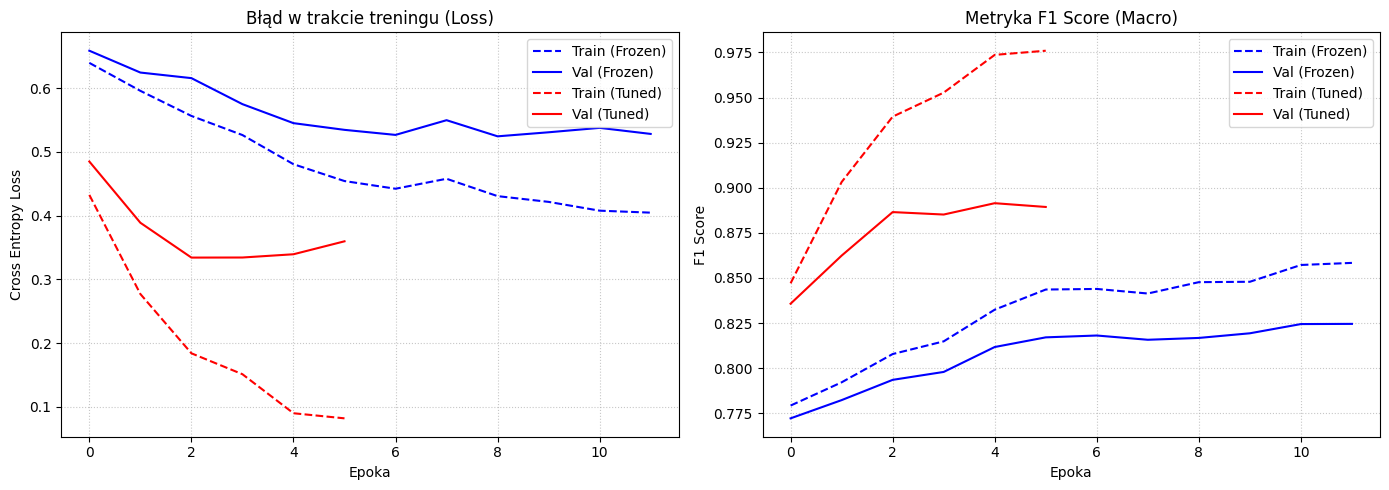

In [18]:
import matplotlib.pyplot as plt

def plot_comparison(history_frozen, history_tuned):
    # Tworzymy obszar z dwoma wykresami obok siebie
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ==========================================
    # 1. Wykres LOSS (Błąd)
    # ==========================================
    # Model Frozen (Niebieski)
    ax1.plot(history_frozen['train_loss'], label='Train (Frozen)', color='blue', linestyle='--')
    ax1.plot(history_frozen['val_loss'], label='Val (Frozen)', color='blue', linestyle='-')
    
    # Model Tuned (Czerwony)
    ax1.plot(history_tuned['train_loss'], label='Train (Tuned)', color='red', linestyle='--')
    ax1.plot(history_tuned['val_loss'], label='Val (Tuned)', color='red', linestyle='-')
    
    ax1.set_title('Błąd w trakcie treningu (Loss)')
    ax1.set_xlabel('Epoka')
    ax1.set_ylabel('Cross Entropy Loss')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()
    
    # ==========================================
    # 2. Wykres F1 SCORE (Metryka)
    # ==========================================
    # Model Frozen (Niebieski)
    ax2.plot(history_frozen['train_f1'], label='Train (Frozen)', color='blue', linestyle='--')
    ax2.plot(history_frozen['val_f1'], label='Val (Frozen)', color='blue', linestyle='-')
    
    # Model Tuned (Czerwony)
    ax2.plot(history_tuned['train_f1'], label='Train (Tuned)', color='red', linestyle='--')
    ax2.plot(history_tuned['val_f1'], label='Val (Tuned)', color='red', linestyle='-')
    
    ax2.set_title('Metryka F1 Score (Macro)')
    ax2.set_xlabel('Epoka')
    ax2.set_ylabel('F1 Score')
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()
    
    # Optymalne ułożenie i wyświetlenie
    plt.tight_layout()
    plt.show()

# Wywołanie funkcji:
plot_comparison(history_frozen, history_tuned)


# Zadanie 3

Spróbuj wydobyć cechy za pomocą samodzielmnie wybranego modelu dostępnego w `torchvision.models` (innego niż VGG) a następnie wyuczyć model MLP oparty o cechy na wyjściu konwolucyjnej części całej architektury. Porównaj wynik z tymi, które uzyskała sieć oparta o LabVGG19.

In [ ]:
import torchvision.models as models

class LabEfficientNet(nn.Module):
    def __init__(self, num_classes=10, freeze_features=True):
        super().__init__()
        
        effnet = models.efficientnet_b0(pretrained=True)
        
        # Wszystko oprócz ostatniej warstwy klasyfikatora
        self.features = effnet.features  # + avgpool osobno
        self.pool = effnet.avgpool
        
        if freeze_features:
            for param in self.features.parameters():
                param.requires_grad = False
        
        # EfficientNet-B0 daje 1280 cech po poolingu
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


In [ ]:
print("Rozpoczynam trening modelu opartego na EfficientNet-B0 (ZAMROŻONE warstwy konwolucyjne)...")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

full_train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=True, download=True)
train_ds, val_ds = random_split(full_train_ds, [int(0.9 * len(full_train_ds)), len(full_train_ds) - int(0.9 * len(full_train_ds))])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)

model = LabEfficientNet(num_classes=10, freeze_features=True)
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)  # tylko klasyfikator

loss_fn = nn.CrossEntropyLoss()

# Używamy tej samej instancji funkcji kosztu (CrossEntropyLoss)
history_resnet = fit(
    model=model, 
    optimiser=optimizer,
    loss_fn=loss_fn,  
    train_dl=train_dl, 
    val_dl=val_dl, 
    epochs=15,
    patience=3,
    print_metrics=True
)


Rozpoczynam trening modelu opartego na ResNet18 (ZAMROŻONE warstwy konwolucyjne)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:08<00:00, 5.62MB/s]
Epoch 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:18<00:00, 77.02it/s]


Epoch 0: train loss = 1.582 (acc: 0.445, f1: 0.442), val loss = 1.576 (acc: 0.451, f1: 0.446)


Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:18<00:00, 76.50it/s]


Epoch 1: train loss = 1.542 (acc: 0.465, f1: 0.460), val loss = 1.538 (acc: 0.462, f1: 0.455)


...

Epoch 12: train loss = 1.419 (acc: 0.503, f1: 0.500), val loss = 1.470 (acc: 0.488, f1: 0.485)


Epoch 13: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:17<00:00, 80.64it/s]


Epoch 13: train loss = 1.404 (acc: 0.509, f1: 0.506), val loss = 1.463 (acc: 0.499, f1: 0.494)


Epoch 14: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407/1407 [00:18<00:00, 76.49it/s]


Epoch 14: train loss = 1.404 (acc: 0.504, f1: 0.500), val loss = 1.465 (acc: 0.489, f1: 0.485)


# Transfer stylu

Jedną z ciekawszych demonstracji tego, jak wykorzystać można cechy wyciągane z gotowego modelu jest tzw. transfer stylu - jedno z klasycznych "pokazowych" zastosowań głębokiego uczenia. Tutaj spróbujemy klasycznego podejścia, o wąskiej definicji stylu obejmującej właściwości tekstury obrazu. Obecne metody opierają się raczej o modele dyfuzyjne, w których zarówno zawartość jak i styl są częścią jednej semantycznej przestrzeni reprezentacji (często na podstawie wejścia tekstowego).

Transfer stylu opisany został w roku 2015, w publikacji *A Neural Algorithm of Artistic Style*

https://arxiv.org/abs/1508.06576

To oryginalne, najbardziej klasyczne podejście opiera się optymalizację w przestrzeni obrazu. Parametrem nie jest tutaj sieć, ale właśnie obrazek który próbujemy stworzyć. Dla zadanego obrazka definiującego treść i obrazka definiującego styl skorzystamy z cech zwróconych przez sieć VGG, aby obliczyć dwie funkcje kosztu - koszt treści i stylu. Następnie będziemy optymalizować generowany obraz tak, aby zminimalizować koszt treści względem obrazu określającego pożądaną treść, oraz zminimalizować koszt stylu względem obrazu określającego pożądany styl. Efektem, jeśli wszystko się uda, będzie nowe dzieło, przedstawiające treść obrazka pierwszego *w stylu* obrazka drugiego.

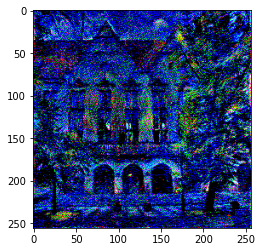

Jak zdefiniować koszt treści? Tutaj rozwiązanie jest proste - błąd średniokwadratowy pomiędzy cechami zwróconymi przez VGG z obrazu docelowego, a tymi zwróconymi z obrazu optymalizowanego. Chcemy żeby nasz obrazek zawierał tę samą treść, a więc oczekujemy, że jego cechy wykrywane przez wyuczony na zadaniu rozpoznawania obiektów model będą podobne.




In [ ]:
import torch.nn.functional as F

def content_loss(content_features, input_features):
  return F.mse_loss(content_features, input_features)

Styl/tekstura to trochę bardziej skomplikowane pojęcie. W tym przypadku będziemy o nim myśleć w kategorii rozkładu cech występujących na całej powierzchni obrazu, niezależnie od położenia. Autorzy klasycznego podejścia wybrali jako matematyczny obiekt opisujący ten rozkład macierz Grama:

https://en.wikipedia.org/wiki/Gramian_matrix

Macierz taka jest własnością pewnego zbioru wektorów i aby przybliżyć jej definicję, zamiast korzystać ze wzorów spójrzmy po prostu na implementację:

In [ ]:
def calculate_gram_matrices(feature_tensor):
  # zakładamy paczkę map cech na wejściu - a to wymiar batcha
  a,b,c,d = feature_tensor.shape
  reshaped_features = feature_tensor.view(a,b,c*d)
  # wyjście ma wymiar (a,b,b) - jest paczką macierzy
  return torch.matmul(reshaped_features, reshaped_features.transpose(1,2))

Powyższy kod zwraca dla batcha wejściowego, batch macierzy Grama. Możemy myśleć o macierzy Grama jako o obiekcie powiązanym z *macierzą kowariancji* rozkładu cech. Istotne różnice: wektory przy wyliczaniu macierzy Grama nie są przesunięte o średnią, zaś wynik nie jest dzielony przez liczbę punktów, więc nie jest to wartość oczekiwana. To ta druga różnica sprawia, że mówimy o własności *zbioru wektorów* zamiast o własności *rozkładu* - bo elementy macierzy Grama będą zwiększać się z większą liczbą uwzględnionych punktów.
(Naszym zbiorem będzie w tym przypadku *zbiór wszystkich pikseli w danej mapie cech*.) Jeżeli jednak wykorzystujemy obrazy treści i stylu o tym samym rozmiarze co rozmiar obrazu generowanego, ta różnica staje się pomijalna.

Stąd łatwo już przejść do definicji kosztu: kosztem stylu będzie błąd średniokwadratowy pomiędzy macierzami grama opisującymi odpowiednie mapy cech:



In [ ]:
def style_loss(style_features, input_features):
  return F.mse_loss(calculate_gram_matrices(style_features), calculate_gram_matrices(input_features))

Pozostaje pytanie, na jakim poziomie wyciągać z architektury cechy? Tutaj jednoznacznej odpowiedzi nie ma, acz typowo stylu szukać będziemy na niższych poziomach, niż treści. W praktyce jednak najlepsze wyniki osiągniemy, próbując dopasować rozwiązanie do konkretnej pary obrazów styl/treść i konkrentej rozdzielczości.

Jescze jedna uwaga na koniec: zauważ, że transfer stylu jest dobrym przykladem zadania gdzie **zawsze** będziemy zamrażać architekturę wydobywającą cechy. Dlaczego? Douczanie ekstraktora cech ułatwiałoby osiągnięcie optimum funkcji kosztu (patrząc na samą wartość). Ale w żaden sposób nie zapewnialibyśmy przy tym, że wydobywane cechy dalej mają coś wspólnego z semantycznymi cechami obrazu. Globalnym optimum w przestrzeni parametrów: obrazu i sieci, byłby ekstraktor który niezależnie od wejścia, zeruje wartości wszystkich cech!

# Zadanie 4

Zaimplementuj transfer stylu, wykorzystując LabVGG19 aby otrzymać cechy na różnych poziomach architektury. Algorytm transferu stylu powinien wykonywać `num_steps` kroków optymalizatora LBFGS, optymalizującego obrazek `input_img` względem kosztów stylu i treści. Koszty stylu i treści powinny być wyliczane na wybieranym parametrem poziomie architektury. Po zakończeniu wyświetl wygenerowany obraz. (Pamiętaj odwróceniu wstępnej operacji normalizacji VGG!)

Przy rozwiązywaniu zadania:

* **nie** modyfikuj funkcji wyliczającej Gram matrix
* zwróć uwagę na różnicę w wartościach poszczególnych kosztów i pamiętaj, że "sensowne" wagi składników kosztu mogą różnić się o kilka rzędów wielkości; postaraj się samemu ustawić je tak, aby osiągnąć wizualnie interesujący wynik
* przetestuj zarówno inicjalizację wartościami losowymi, jak i oryginalnym obrazem treści i zwróć uwagę na różnice wizualne
* możesz dodać składnik kosztu "wygładzający" obrazek (obecny w wielu gotowych implementacjach), ale wtedy porównaj jego wynik z wynikiem gdzie ten składnik jest wyłączony

Pamiętając, że koszty: stylu i treści można wyliczac na różnych poziomach architektury oraz z różnymi wagami, spróbuj dopasować te aspekty algorytmu aby uzyskać interesujący wizualnie efekt.

In [ ]:
from PIL import Image

imsize = (128,128) # imsize można dowolnie zmienić na potrzeby własnych obrazów stylu i treści

def image_loader(image_name):
    image = Image.open(image_name)
    transform = transforms.Compose([
      transforms.Resize(imsize),
      transforms.ToTensor(),
      transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
    return transform(image)

style_img = image_loader("style.jpg")
content_img = image_loader("content.jpg")

input_img = torch.randn(8, 3, imsize[0], imsize[1]) #.cuda(), jeżeli na GPU

# empirycznie, optymalizator LBFGS osiąga w tym zadaniu wyniki lepsze niż Adam
# pominiemy tu wykonywanie testów pokazujących tę przewage i od razu użyjemy LBFGS
optimizer = optim.LBFGS([input_img.requires_grad_()])
# uwaga! LBFGS będzie wymagał opakowania kodu pojedyńczego kroku w funkcję closure
# patrz https://pytorch.org/docs/stable/optim.html


def run_style_transfer(content_img, style_img, input_img, num_steps=300,
                       content_weight=1, style_weight=1e6,
                       content_level=1, style_level=0):

    vgg = LabVGG19()
    vgg.eval()
    for param in vgg.parameters():
        param.requires_grad = False

    # Dodaj wymiar batcha jeśli obrazy są 3D
    def to_batch(img):
        return img.unsqueeze(0) if img.dim() == 3 else img

    content_img = to_batch(content_img)
    style_img   = to_batch(style_img)
    input_img   = to_batch(input_img)

    # Oblicz docelowe cechy raz — VGG nie zmienia wag
    with torch.no_grad():
        target_content = vgg(content_img)[content_level]
        target_style   = vgg(style_img)[style_level]

    input_img = input_img.requires_grad_(True)
    optimizer = optim.LBFGS([input_img])

    step = [0]
    while step[0] < num_steps:
        def closure():
            with torch.no_grad():
                input_img.clamp_(-3, 3)

            optimizer.zero_grad()
            feats = vgg(input_img)

            c_loss = content_weight * content_loss(target_content, feats[content_level])
            s_loss = style_weight   * style_loss(target_style,   feats[style_level])
            loss = c_loss + s_loss
            loss.backward()

            step[0] += 1
            if step[0] % 50 == 0:
                print(f"Step {step[0]}/{num_steps}  content={c_loss.item():.4f}  style={s_loss.item():.4f}")

            return loss

        optimizer.step(closure)

    # Odwróć normalizację VGG i wyświetl
    with torch.no_grad():
        out = input_img.squeeze(0).cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        out  = (out * std + mean).clamp(0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(out.permute(1, 2, 0))
    plt.axis('off')
    plt.title('Transfer Stylu')
    plt.show()

    return out

result = run_style_transfer(
    content_img=content_img,
    style_img=style_img,
    input_img=input_img,
    num_steps=300,
    content_weight=1,
    style_weight=1e6,   # styl zwykle potrzebuje dużo większej wagi
    content_level=1,    # poziom 1 lub 2 dla treści (głębsze = semantyka)
    style_level=0       # poziom 0 dla stylu (niższe = tekstury)
)
